# A8 — Baseline Comparison

Single notebook comparing all five methods (deg=5 $/MWh, tol=5 MW):

| Method | Description |
|---|---|
| Single-SAC | Online RL, single agent |
| Inde-DASAC | Online RL, independent dual agents |
| Coop-DASAC | Online RL, cooperative QMIX |
| Coop-DABC  | Offline RL, TD3+BC + QMIX |
| MPC        | Rolling-horizon MILP (8-step LSTM + ToD mean) |

In [ ]:
import sys, os, json, subprocess, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
warnings.filterwarnings('ignore')

try:
    from tqdm import tqdm
    USE_TQDM = True
except ImportError:
    USE_TQDM = False

CODE_DIR      = os.path.abspath(os.path.join('..', 'code'))
BASELINE_DIR  = os.path.abspath(os.path.join('..', 'results', 'baseline'))
ANALYSIS_DIR  = os.path.abspath('.')
os.makedirs(BASELINE_DIR, exist_ok=True)

sys.path.insert(0, CODE_DIR)

from data.settings import Data_Train, Data_Test, Parameters

DEG, TOL = 5.0, 5.0
SEEDS = list(range(10))   # seeds 0–9

RL_METHODS = {
    'single_sac': 'Single-SAC',
    'inde_sac':   'Inde-DASAC',
    'coop_sac':   'Coop-DASAC',
    'coop_bc':    'Coop-DABC',
}

def baseline_path(algo, seed):
    return os.path.join(BASELINE_DIR, f'result_{algo}_deg{DEG}_tol{TOL}_seed{seed}.json')

MPC_CACHE = os.path.join(BASELINE_DIR, 'mpc_daily.json')

print('Setup done. Parameters:', Parameters)
print(f'Baseline dir: {BASELINE_DIR}')
print(f'Seeds: {SEEDS}')


## Step 1 — MPC: Time-of-day means from training data

In [2]:
pb_train = np.asarray(Data_Train['Data_Price_Bid'], dtype=float)  # (N_tr, 8)
po_train = np.asarray(Data_Train['Data_Price_Ope'], dtype=float)
sb_train = np.asarray(Data_Train['Data_Solar_Bid'], dtype=float).flatten()
so_train = np.asarray(Data_Train['Data_Solar_Ope'], dtype=float).flatten()
N_train  = len(pb_train)

mean_lmp_bid_q   = np.array([pb_train[q::96, 0].mean() for q in range(96)])
mean_lmp_ope_q   = np.array([po_train[q::96, 0].mean() for q in range(96)])
mean_solar_bid_q = np.array([np.clip(sb_train[q::96], 0, None).mean() for q in range(96)])
mean_solar_ope_q = np.array([np.clip(so_train[q::96], 0, None).mean() for q in range(96)])

print(f'Train: {N_train} steps ({N_train//96} days)')
print(f'Mean bid price: {mean_lmp_bid_q.mean():.2f}  Mean ope price: {mean_lmp_ope_q.mean():.2f}')

Train: 13056 steps (136 days)
Mean bid price: 8.29  Mean ope price: 8.06


## Step 2 — MPC: MILP solver

In [3]:
CAP_ESS     = float(Parameters['Cap_ESS'])
CAP_PCS     = float(Parameters['Cap_Pcs_Bid'])
EFF         = float(Parameters['Delta'])
DEGRAD_COST = DEG * 0.25        # $/MW per 15-min interval
M_BIG       = 1e6


def build_forecast(t_abs, lstm_arr, mean_q, n_lstm=8):
    """8-step LSTM forecast + time-of-day mean fill for remaining day."""
    q        = t_abs % 96
    n_remain = 96 - q
    arr      = np.zeros(n_remain)
    n_use    = min(n_lstm, n_remain)
    arr[:n_use] = lstm_arr[t_abs, :n_use]
    for j in range(n_use, n_remain):
        arr[j] = mean_q[(q + j) % 96]
    return arr


def mpc_bid_solve(soc_init, lmp_bid, sol_bid):
    """Stage 1 — DA bid MILP: optimise commit using DA price forecasts only.

    Returns dict with B_Cha[0], B_Dis[0], commit_vec (length n); or None.
    """
    n = len(lmp_bid)

    B_Cha  = cp.Variable(n, nonneg=True);  B_Dis  = cp.Variable(n, nonneg=True)
    B_Sell = cp.Variable(n, nonneg=True);  B_Purc = cp.Variable(n, nonneg=True)
    SoC_b  = cp.Variable(n, nonneg=True)
    zb     = cp.Variable(n, boolean=True); zb_    = cp.Variable(n, boolean=True)

    con = []
    for q in range(n):
        sp = soc_init if q == 0 else SoC_b[q - 1]
        con += [
            B_Sell[q] == B_Purc[q] + sol_bid[q] + B_Dis[q] - B_Cha[q],
            B_Cha[q]  <= CAP_PCS,  B_Dis[q]  <= CAP_PCS,
            SoC_b[q]  <= CAP_ESS,
            B_Sell[q] <= M_BIG * zb[q],   B_Purc[q] <= M_BIG * (1 - zb[q]),
            B_Cha[q]  <= M_BIG * zb_[q],  B_Dis[q]  <= M_BIG * (1 - zb_[q]),
            SoC_b[q]  == sp + B_Cha[q] * EFF - B_Dis[q] / EFF,
        ]
    con += [SoC_b[n - 1] == 0]

    prob = cp.Problem(cp.Maximize((B_Sell - B_Purc) @ lmp_bid), con)
    prob.solve(solver=cp.HIGHS)

    if prob.status in ('infeasible', 'unbounded') or B_Cha.value is None:
        return None
    return {
        'B_Cha':      float(B_Cha.value[0]),
        'B_Dis':      float(B_Dis.value[0]),
        'commit_vec': (B_Sell.value - B_Purc.value).copy(),
    }


def mpc_ope_solve(soc_init, lmp_ope, sol_ope, commit_vec):
    """Stage 2 — RT operation MILP: optimise sell_ope with commit fixed.

    Objective: (O_Sell - O_Purc) @ lmp_ope - deg.
    B_Sell/B_Purc are constants from Stage 1, so dropped from objective.
    Tolerance constraint: |sell_ope - commit| <= TOL enforced per step.
    """
    n = len(lmp_ope)

    O_Cha  = cp.Variable(n, nonneg=True);  O_Dis  = cp.Variable(n, nonneg=True)
    O_Sell = cp.Variable(n, nonneg=True);  O_Purc = cp.Variable(n, nonneg=True)
    SoC    = cp.Variable(n, nonneg=True)
    zo     = cp.Variable(n, boolean=True); zo_    = cp.Variable(n, boolean=True)

    con = []
    for q in range(n):
        sp = soc_init if q == 0 else SoC[q - 1]
        cq = float(commit_vec[q])
        con += [
            O_Sell[q] == O_Purc[q] + sol_ope[q] + O_Dis[q] - O_Cha[q],
            O_Cha[q]  <= CAP_PCS,  O_Dis[q]  <= CAP_PCS,
            SoC[q]    <= CAP_ESS,
            O_Sell[q] <= M_BIG * zo[q],   O_Purc[q] <= M_BIG * (1 - zo[q]),
            O_Cha[q]  <= M_BIG * zo_[q],  O_Dis[q]  <= M_BIG * (1 - zo_[q]),
            SoC[q]    == sp + O_Cha[q] * EFF - O_Dis[q] / EFF,
            # tolerance constraint: sell_ope within ±TOL of commit
            O_Sell[q] - O_Purc[q] <= cq + TOL,
            O_Sell[q] - O_Purc[q] >= cq - TOL,
        ]
    con += [SoC[n - 1] == 0]

    profit_ope  = (O_Sell - O_Purc) @ lmp_ope
    degradation = cp.sum(O_Dis + O_Cha) * DEGRAD_COST

    prob = cp.Problem(cp.Maximize(profit_ope - degradation), con)
    prob.solve(solver=cp.HIGHS)

    if prob.status in ('infeasible', 'unbounded') or O_Cha.value is None:
        return None
    return {
        'O_Cha': float(O_Cha.value[0]),
        'O_Dis': float(O_Dis.value[0]),
    }


print(f'Two-stage MILP ready. DEGRAD_COST={DEGRAD_COST} $/MW/interval, CAP_PCS={CAP_PCS} MW')

Two-stage MILP ready. DEGRAD_COST=1.25 $/MW/interval, CAP_PCS=25.0 MW


## Step 3 — MPC: Rolling-horizon loop over test set

In [4]:
pb_test = np.asarray(Data_Test['Data_Price_Bid'], dtype=float)
po_test = np.asarray(Data_Test['Data_Price_Ope'], dtype=float)
ps_test = np.asarray(Data_Test['Data_Price_Set'], dtype=float).flatten()
sb_test = np.asarray(Data_Test['Data_Solar_Bid'], dtype=float).flatten()
so_test = np.asarray(Data_Test['Data_Solar_Ope'], dtype=float).flatten()
N_test  = len(ps_test)
N_DAYS  = N_test // 96

# ── Load cached MPC results if available ────────────────────────────────────
if os.path.exists(MPC_CACHE):
    print(f'[SKIP] MPC — loading cached results from {MPC_CACHE}')
    with open(MPC_CACHE) as f:
        mpc_daily = json.load(f)
    mpc_arr = np.array(mpc_daily)
    print(f'Total={mpc_arr[:,3].sum():,.0f}  '
          f'Bid={mpc_arr[:,0].sum():,.0f}  '
          f'Ope={mpc_arr[:,1].sum():,.0f}  '
          f'Deg={mpc_arr[:,2].sum():,.0f}')
else:
    mpc_daily = []
    n_failed  = 0
    t0_total  = time.time()

    day_iter = tqdm(range(N_DAYS), desc='MPC') if USE_TQDM else range(N_DAYS)

    for day in day_iter:
        soc   = 0.0
        d_bid = d_ope = d_deg = 0.0

        for q in range(96):
            t = day * 96 + q

            lmp_bid_arr = build_forecast(t, pb_test, mean_lmp_bid_q)
            lmp_ope_arr = build_forecast(t, po_test, mean_lmp_ope_q)

            n_rem = 96 - q
            sol_b = np.array([max(0., float(sb_test[t]))] +
                             [mean_solar_bid_q[(q+j) % 96] for j in range(1, n_rem)])
            sol_o = np.array([max(0., float(so_test[t]))] +
                             [mean_solar_ope_q[(q+j) % 96] for j in range(1, n_rem)])

            # Stage 1: DA bid MILP (DA price forecasts only)
            bid_res = mpc_bid_solve(soc, lmp_bid_arr, sol_b)
            if bid_res is None:
                n_failed += 1
                B_Cha0     = B_Dis0 = 0.0
                commit_vec = np.zeros(n_rem)
            else:
                B_Cha0     = max(0., bid_res['B_Cha'])
                B_Dis0     = max(0., bid_res['B_Dis'])
                commit_vec = bid_res['commit_vec']

            # Stage 2: RT operation MILP (commit fixed, tolerance constraint applied)
            ope_res = mpc_ope_solve(soc, lmp_ope_arr, sol_o, commit_vec)
            if ope_res is None:
                n_failed += 1
                O_Cha0 = O_Dis0 = 0.0
            else:
                O_Cha0 = max(0., ope_res['O_Cha'])
                O_Dis0 = max(0., ope_res['O_Dis'])

            sell_bid = max(0., float(sb_test[t])) + B_Dis0 - B_Cha0
            sell_ope = max(0., float(so_test[t])) + O_Dis0 - O_Cha0
            act_ope  = O_Cha0 - O_Dis0

            r_bid = sell_bid * float(po_test[t, 0])
            r_ope = (sell_ope - sell_bid) * float(ps_test[t])
            r_deg = -abs(act_ope) * DEGRAD_COST

            d_bid += r_bid;  d_ope += r_ope;  d_deg += r_deg
            soc = float(np.clip(soc + O_Cha0 * EFF - O_Dis0 / EFF, 0.0, CAP_ESS))

        mpc_daily.append([d_bid, d_ope, d_deg, d_bid + d_ope + d_deg])

        if not USE_TQDM and (day + 1) % 5 == 0:
            cum = sum(r[3] for r in mpc_daily)
            print(f'Day {day+1}/{N_DAYS}  cum={cum:,.0f}', flush=True)

    mpc_arr = np.array(mpc_daily)
    elapsed = time.time() - t0_total
    print(f'\nMPC done in {elapsed:.0f}s  failed={n_failed}/{N_test}')
    print(f'Total={mpc_arr[:,3].sum():,.0f}  '
          f'Bid={mpc_arr[:,0].sum():,.0f}  '
          f'Ope={mpc_arr[:,1].sum():,.0f}  '
          f'Deg={mpc_arr[:,2].sum():,.0f}')

    with open(MPC_CACHE, 'w') as f:
        json.dump(mpc_arr.tolist(), f)
    print(f'[Saved] MPC cache → {MPC_CACHE}')

[SKIP] MPC — loading cached results from c:\Users\WJ\OneDrive\바탕 화면\Research_Real time energy bid\APEN_Major_Revision\results\baseline\mpc_daily.json
Total=133,682  Bid=143,568  Ope=7,341  Deg=-17,227


## Step 4 — Train missing RL models

In [ ]:
python_exe = sys.executable
run_script = os.path.join(CODE_DIR, 'run_training.py')

for algo in ['single_sac', 'inde_sac', 'coop_sac', 'coop_bc']:
    for seed in SEEDS:
        if os.path.exists(baseline_path(algo, seed)):
            print(f'[SKIP] {algo}  seed={seed}')
            continue

        print(f'[RUN ] {algo}  seed={seed}', flush=True)
        t0  = time.time()
        cmd = [
            python_exe, run_script,
            '--algo',     algo,
            '--deg_cost', str(DEG),
            '--tol',      str(TOL),
            '--seed',     str(seed),
            '--save_dir', os.path.abspath(BASELINE_DIR),
        ]

        # ── Live training log suppressed (too verbose). Output is captured and
        #    only printed if the run fails. To restore live streaming, uncomment:
        # with subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        #                       text=True, bufsize=1, cwd=CODE_DIR) as proc:
        #     for line in proc.stdout:
        #         print(line, end='', flush=True)
        #     proc.wait()
        proc = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                              text=True, cwd=CODE_DIR)

        elapsed = time.time() - t0
        if proc.returncode != 0:
            print(f'  [ERROR] exit code {proc.returncode}')
            print(proc.stdout[-3000:])   # tail of captured log for debugging
        else:
            print(f'  done in {elapsed:.0f}s')

print('\nAll RL training done.')


## Step 4b — Validation Curves

In [ ]:

# ── Validation curves: 10-seed mean ± std, smoothed ──────────────────────────
def _smooth(arr, w):
    if w <= 1:
        return arr
    kernel = np.ones(w) / w
    pad    = w // 2
    padded = np.pad(arr, pad, mode='edge')
    return np.convolve(padded, kernel, mode='valid')[:len(arr)]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (algo, label) in zip(axes.flatten(), RL_METHODS.items()):
    all_rets   = []
    eval_freq  = 1 if algo == 'coop_bc' else 50   # fallback; overwritten from JSON if present

    for seed in SEEDS:
        path = baseline_path(algo, seed)
        if not os.path.exists(path):
            continue
        with open(path) as f:
            d = json.load(f)
        vr = d.get('val_returns', [])
        if not vr:
            continue
        eval_freq = d.get('eval_freq', eval_freq)  # use stored eval_freq
        all_rets.append(vr)

    if not all_rets:
        ax.set_title(f'{label} — MISSING'); ax.axis('off'); continue

    n    = min(len(r) for r in all_rets)
    arr  = np.array([r[:n] for r in all_rets], dtype=float)   # (n_seeds, n)
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    steps = np.arange(n) * eval_freq

    w       = max(1, n // 10)   # smooth window ≈ 10% of curve length
    mean_s  = _smooth(mean, w)
    std_s   = _smooth(std,  w)

    # peak of the *mean* curve (each seed's own best step differs; this is the mean-curve max)
    pk      = int(np.argmax(mean_s))
    pk_val  = float(mean_s[pk])

    ax.plot(steps, mean_s, linewidth=1.5, color='#4878CF',
            label=f'Mean ({len(all_rets)} seeds)')
    ax.fill_between(steps, mean_s - std_s, mean_s + std_s,
                    alpha=0.25, color='#4878CF', label='±1 std')
    ax.axhline(pk_val, color='red', linestyle='--', linewidth=0.9, alpha=0.7)
    ax.scatter([steps[pk]], [pk_val], color='red', s=50, zorder=5,
               label=f'Max of mean = {pk_val:,.0f}')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Training step')
    ax.set_ylabel('Validation return')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))

plt.suptitle('Validation Return — 10-seed mean ± std (smoothed)', fontsize=13, y=1.01)
plt.tight_layout()
save_path = os.path.join(ANALYSIS_DIR, 'A8_Validation_Curves.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')


### Per-seed validation curves (individual seeds)

In [ ]:

# Per-seed validation curves. Legend shows each seed's BEST (peak of the smoothed
# curve); the reported test uses the best-validation checkpoint (test = best-val weights).
SEED_COLORS = list(plt.cm.tab10.colors)   # 10 distinct colors

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (algo, label) in zip(axes.flatten(), RL_METHODS.items()):
    eval_freq = 1 if algo == 'coop_bc' else 50
    plotted   = 0

    for seed in SEEDS:
        path = baseline_path(algo, seed)
        if not os.path.exists(path):
            continue
        with open(path) as f:
            d = json.load(f)
        vr = d.get('val_returns', [])
        if not vr:
            continue
        eval_freq = d.get('eval_freq', eval_freq)

        vr     = np.array(vr, dtype=float)
        vr_s   = _smooth(vr, max(1, len(vr) // 10))
        steps  = np.arange(len(vr)) * eval_freq
        bi     = int(np.argmax(vr_s))            # peak of smoothed curve (dot sits on the curve)
        best   = float(vr_s[bi])

        ax.plot(steps, vr_s, linewidth=1.3, color=SEED_COLORS[seed % len(SEED_COLORS)],
                label=f'seed {seed}  (best={best:,.0f})', alpha=0.85)
        ax.scatter([steps[bi]], [best], color=SEED_COLORS[seed % len(SEED_COLORS)],
                   s=22, zorder=5, edgecolor='white', linewidth=0.4)
        plotted += 1

    if plotted == 0:
        ax.set_title(f'{label} — MISSING'); ax.axis('off'); continue

    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Training step')
    ax.set_ylabel('Validation return')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))

plt.suptitle('Per-seed validation curves  (dot = peak of smoothed curve; test uses best-val checkpoint)',
             fontsize=13, y=1.01)
plt.tight_layout()
save_path = os.path.join(ANALYSIS_DIR, 'A8_PerSeed_Curves.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')


## Step 5 — Aggregate results

In [ ]:
results = {}

# ── RL methods: average test metrics across all seeds ────────────────────────
for algo, label in RL_METHODS.items():
    seed_data = []
    for seed in SEEDS:
        path = baseline_path(algo, seed)
        if not os.path.exists(path):
            continue
        with open(path) as f:
            d = json.load(f)
        seed_data.append(d)

    if not seed_data:
        print(f'[MISSING] {algo}')
        continue

    results[label] = dict(
        bid  = float(np.mean([d['test_mean_bid']   for d in seed_data])),
        ope  = float(np.mean([d['test_mean_ope']   for d in seed_data])),
        deg  = float(np.mean([d['test_mean_deg']   for d in seed_data])),
        total= float(np.mean([d['test_mean_total'] for d in seed_data])),
        std  = float(np.mean([d['test_std_total']  for d in seed_data])),
        n_seeds=len(seed_data),
    )

# ── MPC from this session ────────────────────────────────────────────────────
results['MPC'] = dict(
    bid=float(mpc_arr[:, 0].mean()), ope=float(mpc_arr[:, 1].mean()),
    deg=float(mpc_arr[:, 2].mean()), total=float(mpc_arr[:, 3].mean()),
    std=float(mpc_arr[:, 3].std()), n_seeds=1,
)

# ── Print ─────────────────────────────────────────────────────────────────────
print(f'{"Method":<15}  {"Bid":>8}  {"Ope":>8}  {"Deg":>8}  {"Total":>8}  {"Std":>8}  {"N":>3}')
print('-' * 70)
for label, r in results.items():
    print(f'{label:<15}  {r["bid"]:>8.0f}  {r["ope"]:>8.0f}  '
          f'{r["deg"]:>8.0f}  {r["total"]:>8.0f}  {r["std"]:>8.0f}  {r["n_seeds"]:>3}')


## Step 6 — Comparison Table

In [8]:
rows = [
    {
        'Method':           label,
        'DA Bid ($/day)':   f"{r['bid']:,.0f}",
        'RT Ope ($/day)':   f"{r['ope']:,.0f}",
        'Degradation':      f"{r['deg']:,.0f}",
        'Total ($/day)':    f"{r['total']:,.0f}",
        'Std':              f"{r['std']:,.0f}",
    }
    for label, r in results.items()
]
df = pd.DataFrame(rows).set_index('Method')
df

,DA Bid ($/day),RT Ope ($/day),Degradation,Total ($/day),Std
Method,,,,,
Single-SAC,"4,117",100,-16,"4,200","1,894"
Inde-DASAC,"4,108",105,-9,"4,204","1,898"
Coop-DASAC,"4,392",117,-79,"4,430","1,682"
Coop-DABC,"5,750",-660,-357,"4,732","1,863"
MPC,"4,786",245,-574,"4,456","1,887"


## Step 7 — Plots

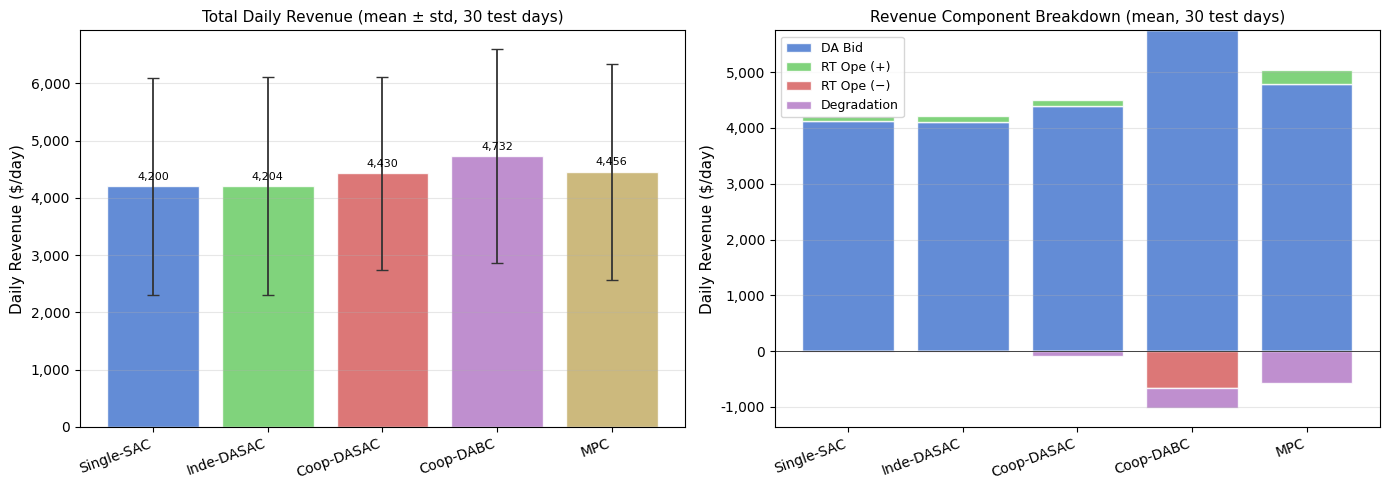

Saved: c:\Users\WJ\OneDrive\바탕 화면\Research_Real time energy bid\APEN_Major_Revision\analysis\A8_Baseline_Comparison.png


In [9]:
labels = list(results.keys())
x      = np.arange(len(labels))
COLORS = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66']

totals = [results[l]['total'] for l in labels]
stds   = [results[l]['std']   for l in labels]
bids   = np.array([results[l]['bid'] for l in labels])
opes   = np.array([results[l]['ope'] for l in labels])
degs   = np.array([results[l]['deg'] for l in labels])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: total revenue + std ─────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(x, totals, color=COLORS[:len(labels)], alpha=0.85, edgecolor='white')
ax.errorbar(x, totals, yerr=stds, fmt='none', color='#333', capsize=4, linewidth=1.3)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Daily Revenue ($/day)', fontsize=11)
ax.set_title('Total Daily Revenue (mean ± std, 30 test days)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width()/2,
            max(bar.get_height(), 0) + max(stds) * 0.04,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=8)

# ── Right: stacked component breakdown ───────────────────────────────────────
ax = axes[1]
ope_pos = np.maximum(opes, 0)
ope_neg = np.minimum(opes, 0)

ax.bar(x, bids,    label='DA Bid',     color='#4878CF', alpha=0.85, edgecolor='white')
ax.bar(x, ope_pos, label='RT Ope (+)', color='#6ACC65', alpha=0.85, edgecolor='white', bottom=bids)
ax.bar(x, ope_neg, label='RT Ope (−)', color='#D65F5F', alpha=0.85, edgecolor='white')
ax.bar(x, degs,    label='Degradation',color='#B47CC7', alpha=0.85, edgecolor='white', bottom=ope_neg)

ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Daily Revenue ($/day)', fontsize=11)
ax.set_title('Revenue Component Breakdown (mean, 30 test days)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
save_path = os.path.join(ANALYSIS_DIR, 'A8_Baseline_Comparison.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

## Step 7b — Seed-group comparison (top-3 / all-10 / bottom-3)

Splits each method's 10 seeds into top-3, all-10, and bottom-3 (by test revenue) to show
training-variance: a narrow top↔bottom gap = consistent; a wide gap = high seed variance.

In [ ]:
# Seed-group comparison: top-3 / all-10 / bottom-3 per method (by test revenue)
group = {}
for algo, label in RL_METHODS.items():
    vals = []
    for seed in SEEDS:
        p = baseline_path(algo, seed)
        if os.path.exists(p):
            with open(p) as f:
                vals.append(json.load(f)['test_mean_total'])
    if not vals:
        continue
    vals = np.sort(np.array(vals))
    group[label] = dict(top3=vals[-3:].mean(), all=vals.mean(), bot3=vals[:3].mean(), n=len(vals))

mpc_mean = float(mpc_arr[:, 3].mean())

glabels = list(group.keys()); gx = np.arange(len(glabels)); gw = 0.26
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(gx - gw, [group[l]['top3'] for l in glabels], gw, label='Top-3 seeds',    color='#6ACC65', edgecolor='white')
ax.bar(gx,      [group[l]['all']  for l in glabels], gw, label='All-10 (mean)',  color='#4878CF', edgecolor='white')
ax.bar(gx + gw, [group[l]['bot3'] for l in glabels], gw, label='Bottom-3 seeds', color='#D65F5F', edgecolor='white')
ax.axhline(mpc_mean, color='#C4AD66', ls='--', lw=1.6, label=f'MPC (deterministic) = {mpc_mean:,.0f}')
ax.set_xticks(gx); ax.set_xticklabels(glabels, fontsize=11)
ax.set_ylabel('Mean Daily Test Revenue ($/day)'); ax.set_ylim(3500, None)
ax.set_title('Per-method seed-group comparison (10 seeds): top-3 vs all vs bottom-3\n'
             '(narrow gap = consistent; wide gap = high training variance)', fontsize=12)
ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=9)
for i, l in enumerate(glabels):
    for xpos, key in [(i-gw, 'top3'), (i, 'all'), (i+gw, 'bot3')]:
        ax.text(xpos, group[l][key], f"{group[l][key]:,.0f}", ha='center', va='bottom', fontsize=7)
plt.tight_layout()
save_path = os.path.join(ANALYSIS_DIR, 'A8_SeedGroup_Comparison.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

print(f'\n{"Method":<14}{"top-3":>9}{"all-10":>9}{"bot-3":>9}{"gap":>9}')
for l in glabels:
    g = group[l]; print(f'{l:<14}{g["top3"]:>9.0f}{g["all"]:>9.0f}{g["bot3"]:>9.0f}{g["top3"]-g["bot3"]:>9.0f}')
print(f'{"MPC":<14}{mpc_mean:>9.0f}{mpc_mean:>9.0f}{mpc_mean:>9.0f}{0:>9.0f}')


## Step 8 — MPC daily profit distribution

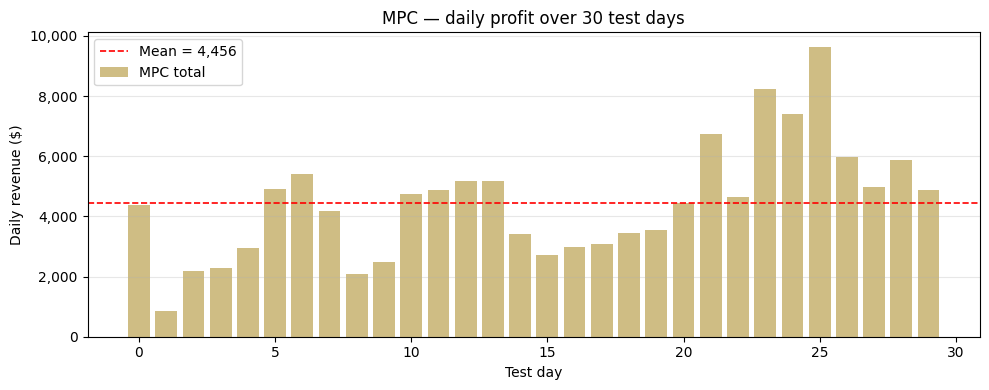

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(N_DAYS), mpc_arr[:, 3], color='#C4AD66', alpha=0.8, label='MPC total')
ax.axhline(mpc_arr[:, 3].mean(), color='red', linestyle='--', linewidth=1.2,
           label=f'Mean = {mpc_arr[:,3].mean():,.0f}')
ax.set_xlabel('Test day'); ax.set_ylabel('Daily revenue ($)')
ax.set_title('MPC — daily profit over 30 test days')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
plt.tight_layout(); plt.show()